In [38]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import hmean
from pingouin import wilcoxon
from statsmodels.stats.multitest import multipletests
import numpy as np

sns.set_theme(style="whitegrid")

In [39]:
def compute_statistics(col_name, table_col, condition, baseline_df, df_geg2, table_tex):
  for data in baseline_df['data'].unique():
    print(data)
    stats = pd.DataFrame()
    baseline_acc = baseline_df[baseline_df['data'] == data][col_name]
    for constraint in df_geg2['constraint'].unique():
      geg_acc = df_geg2[(df_geg2['data'] == data) & (df_geg2['constraint'] == constraint)][col_name]
      stat = wilcoxon(baseline_acc.abs(), geg_acc.abs(), alternative=condition)
      stats = pd.concat([stats, pd.DataFrame({'data': [data], 'constraint': [constraint], 'p-val': stat['p-val']})], ignore_index=True)
    stats.loc[:, 'accept'] = multipletests(stats['p-val'], method='holm')[1]
    for _,stat in stats.iterrows():
      print(stat)
      if stat['accept'] < 0.05:
        table_tex.loc[(table_tex['data'] == stat['data']) & (table_tex['constraint'] == stat['constraint']), table_col] = table_tex.loc[(table_tex['data'] == stat['data']) & (table_tex['constraint'] == stat['constraint']), table_col].apply(lambda x: '\isBetter '+ x )
      elif stat['accept'] >= 0.9:
        table_tex.loc[(table_tex['data'] == stat['data']) & (table_tex['constraint'] == stat['constraint']), table_col] = table_tex.loc[(table_tex['data'] == stat['data']) & (table_tex['constraint'] == stat['constraint']), table_col].apply(lambda x: '\isWorse '+ x )

## RQ1

In [40]:
baseline_df = pd.DataFrame()
for file in os.listdir('results_baseline'):
    if file.endswith('.csv'):
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_baseline', file))
        df['data'] = data
        baseline_df = pd.concat([baseline_df, df], ignore_index=True)
# baseline_df['statistical_parity'] = baseline_df['statistical_parity']
# baseline_df['equal_opportunity'] = baseline_df['equal_opportunity']
# baseline_df['average_odds'] = baseline_df['average_odds']

In [41]:
grouped = baseline_df.groupby('data').agg(['mean', 'std']).reset_index()

In [42]:
grouped_baseline = grouped.drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_98294/2910365511.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_baseline = grouped.drop(columns='fold')


In [43]:
df_geg2 = pd.DataFrame()
for file in os.listdir('results_geg_new'):
    if file.endswith('.csv'):
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_geg_new', file))
        df['data'] = data
        df_geg2 = pd.concat([df_geg2, df], ignore_index=True)
# df_geg2['statistical_parity'] = df_geg2['statistical_parity']
# df_geg2['equal_opportunity'] = df_geg2['equal_opportunity']
# df_geg2['average_odds'] = df_geg2['average_odds']

In [44]:
grouped_geg = df_geg2.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_98294/157383463.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_geg = df_geg2.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')


In [45]:
grouped_baseline['constraint'] = 'baseline'

In [46]:
full_data = pd.concat([grouped_baseline.assign(constraint='baseline'), grouped_geg], ignore_index=True)

In [47]:
full_data['acc'] = full_data[('accuracy', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('accuracy', 'std')].round(3).astype(str)
full_data['prec'] = full_data[('precision', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('precision', 'std')].round(3).astype(str)
full_data['rec'] = full_data[('recall', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('recall', 'std')].round(3).astype(str)
full_data['f1'] = full_data[('f1_score', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('f1_score', 'std')].round(3).astype(str)
full_data['spd'] = full_data[('statistical_parity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('statistical_parity', 'std')].round(3).astype(str)
full_data['eod'] = full_data[('equal_opportunity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('equal_opportunity', 'std')].round(3).astype(str)
full_data['aod'] = full_data[('average_odds', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('average_odds', 'std')].round(3).astype(str)

In [48]:
full_data.sort_values(by=['data', 'constraint'], inplace=True)

In [49]:
table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds'], axis=1)

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_98294/1130035862.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds'], axis=1)


In [50]:
compute_statistics('precision', 'prec', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('recall', 'rec', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('f1_score', 'f1', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('statistical_parity', 'spd', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('equal_opportunity', 'eod', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('average_odds', 'aod', 'greater', baseline_df, df_geg2, table_tex)

cmc
data               cmc
constraint          dp
p-val         0.862305
accept             1.0
Name: 0, dtype: object
data               cmc
constraint          cp
p-val         0.753906
accept             1.0
Name: 1, dtype: object
data               cmc
constraint          eo
p-val         0.919922
accept             1.0
Name: 2, dtype: object
crime
data            crime
constraint         dp
p-val         0.93457
accept            1.0
Name: 0, dtype: object
data            crime
constraint         cp
p-val         0.99707
accept            1.0
Name: 1, dtype: object
data           crime
constraint        eo
p-val         0.8125
accept           1.0
Name: 2, dtype: object
law
data               law
constraint          dp
p-val         0.052734
accept        0.105469
Name: 0, dtype: object
data               law
constraint          cp
p-val         0.001953
accept        0.005859
Name: 1, dtype: object
data              law
constraint         eo
p-val         0.21582
accept        0.

In [51]:
table_tex

,data,constraint,acc,prec,rec,f1,spd,eod,aod
,,,,,,,,,
0,cmc,baseline,0.606$\pm$0.033,0.583$\pm$0.037,0.56$\pm$0.032,0.553$\pm$0.033,0.115$\pm$0.066,0.178$\pm$0.129,0.116$\pm$0.076
7,cmc,cp,0.606$\pm$0.03,\isWorse 0.576$\pm$0.038,\isWorse 0.561$\pm$0.032,\isWorse 0.556$\pm$0.034,\isBetter 0.058$\pm$0.062,0.057$\pm$0.162,\isBetter 0.042$\pm$0.087
8,cmc,dp,0.602$\pm$0.028,\isWorse 0.575$\pm$0.032,\isWorse 0.556$\pm$0.026,\isWorse 0.549$\pm$0.027,\isBetter 0.015$\pm$0.057,-0.045$\pm$0.147,\isBetter -0.02$\pm$0.063
9,cmc,eo,0.601$\pm$0.034,\isWorse 0.574$\pm$0.038,\isWorse 0.56$\pm$0.031,\isWorse 0.557$\pm$0.032,\isBetter 0.028$\pm$0.045,0.01$\pm$0.171,\isBetter 0.007$\pm$0.076
1,crime,baseline,0.474$\pm$0.037,0.434$\pm$0.046,0.452$\pm$0.032,0.427$\pm$0.037,0.382$\pm$0.062,0.266$\pm$0.288,0.247$\pm$0.146
10,crime,cp,0.355$\pm$0.031,\isWorse 0.373$\pm$0.031,\isWorse 0.333$\pm$0.029,\isWorse 0.315$\pm$0.033,\isBetter 0.087$\pm$0.065,0.118$\pm$0.213,\isBetter 0.06$\pm$0.103
11,crime,dp,0.406$\pm$0.04,\isWorse 0.403$\pm$0.035,\isWorse 0.397$\pm$0.038,\isWorse 0.392$\pm$0.035,\isBetter 0.028$\pm$0.048,-0.056$\pm$0.174,\isBetter -0.072$\pm$0.07
12,crime,eo,0.333$\pm$0.077,\isWorse 0.41$\pm$0.107,\isWorse 0.307$\pm$0.081,\isWorse 0.246$\pm$0.11,\isBetter 0.128$\pm$0.111,0.074$\pm$0.234,\isBetter 0.066$\pm$0.136
2,drug,baseline,0.687$\pm$0.023,0.618$\pm$0.033,0.614$\pm$0.018,0.611$\pm$0.025,0.213$\pm$0.125,0.276$\pm$0.181,0.177$\pm$0.1


In [52]:
table_tex.to_latex('results_summary.tex', index=False, escape=False)

### Plots

In [53]:
baseline_df['constraint'] = 'baseline'
df_all = pd.concat([baseline_df, df_geg2], ignore_index=True)
df_all_melt = pd.melt(df_all.drop(columns=['fold']), id_vars=['data', 'constraint'], var_name='metric', value_name='value')

<Axes: xlabel='metric', ylabel='value'>

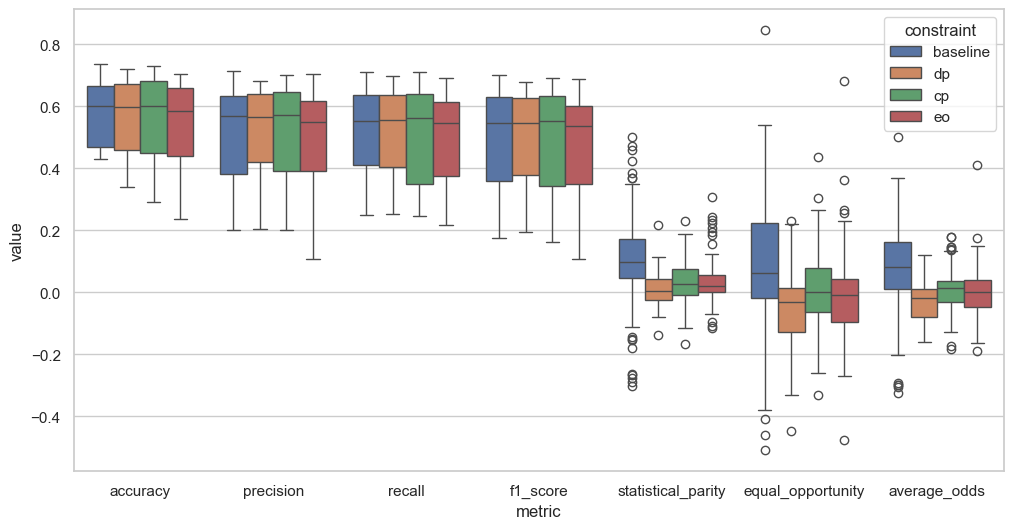

In [54]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_all_melt, x='metric', y='value', hue='constraint')

### Pareto Analysis

In [55]:
df_all

,fold,accuracy,precision,recall,f1_score,statistical_parity,equal_opportunity,average_odds,data,constraint
0,1,0.601351,0.594737,0.554533,0.547905,0.137391,0.392857,0.201905,cmc,baseline
1,2,0.601351,0.585716,0.551966,0.530198,0.054959,0.046154,0.035792,cmc,baseline
2,3,0.587838,0.552368,0.547591,0.547001,0.115871,0.310559,0.135625,cmc,baseline
3,4,0.591837,0.626301,0.563636,0.551525,-0.014228,-0.035842,-0.039660,cmc,baseline
4,5,0.612245,0.567451,0.526398,0.524743,0.118798,0.103896,0.084568,cmc,baseline
...,...,...,...,...,...,...,...,...,...,...
275,6,0.643617,0.602034,0.590049,0.587056,0.195076,-0.126984,0.083073,drug,eo
276,7,0.686170,0.549107,0.586513,0.552400,0.004381,-0.271429,-0.147815,drug,eo
277,8,0.654255,0.569123,0.562585,0.564130,0.046512,-0.161654,-0.036880,drug,eo
278,9,0.659574,0.600930,0.611927,0.598507,-0.097384,-0.210526,-0.145686,drug,eo


In [56]:
from itertools import product
from collections import defaultdict

def pareto_front_two(df,acc,fair):
    df = df.sort_values(by=[acc, fair], ascending=[False, True])
    pareto = []
    for i in range(len(df)):
        if not any((df.iloc[i][acc] <= p[acc] and
                    df.iloc[i][fair] >= p[fair]) for p in pareto):
            pareto.append(df.iloc[i])
    return pd.DataFrame(pareto)

def pareto_front_full(df):
    df = df.sort_values(by=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds'], ascending=[False, False, False, False, True, True, True])
    pareto = []
    for i in range(len(df)):
        if not any((df.iloc[i]['accuracy'] <= p['accuracy'] and
                    df.iloc[i]['precision'] <= p['precision'] and
                    df.iloc[i]['recall'] <= p['recall'] and
                    df.iloc[i]['f1_score'] <= p['f1_score'] and
                    df.iloc[i]['statistical_parity'] >= p['statistical_parity'] and
                    df.iloc[i]['equal_opportunity'] >= p['equal_opportunity'] and
                    df.iloc[i]['average_odds'] >= p['average_odds']) for p in pareto):
            pareto.append(df.iloc[i])
    return pd.DataFrame(pareto)
   

datasets = df_all['data'].unique()
#attrs = ["age","race","sex"]
metricsAcc = ['accuracy', 'precision', 'recall', 'f1_score']
#metricsAcc = ['MCC']
metricsFair = ['statistical_parity', 'equal_opportunity', 'average_odds']
paretoPresent = defaultdict(int)
for dataset in datasets:
  pareto_data = defaultdict(int)
  for mAcc,mFair in product(metricsAcc,metricsFair):
    #filtered = grouped[(grouped["data"]==dataset) & (grouped["attr"]==attr)]
    filtered = df_all[(df_all["data"]==dataset)]
    if not len(filtered):
        continue
    # pareto = pareto_front_two(filtered,mAcc,mFair)
    pareto = pareto_front_full(filtered)
    for x in pareto['constraint'].value_counts().keys():
        paretoPresent[(x,mAcc,mFair)] += 1
        pareto_data[x] += 1

In [60]:
pareto['constraint'].value_counts()

constraint
baseline    7
dp          4
eo          3
cp          2
Name: count, dtype: int64

In [117]:
df_all = pd.DataFrame(
    [(k[0], k[1], k[2], v) for k, v in paretoPresent.items()],
    columns=["method", "acc", "fair", "value"]
)
uniqueMethods = sorted(df_all["method"].unique())
df_all = df_all.sort_values('method')
# Create pivot tables for each metric2, reindex to include all methods, fill missing with 0
dfs = {}
df_all = df_all.sort_values('method')
for m2 in df_all["fair"].unique():
    pivot = df_all[df_all["fair"] == m2].pivot(
        index="method", columns="acc", values="value"
    )
    dfs[m2] = pivot.reindex(uniqueMethods, fill_value=np.nan)

In [118]:
dfs['statistical_parity'].fillna(0, inplace=True)
dfs['equal_opportunity'].fillna(0, inplace=True)
dfs['average_odds'].fillna(0, inplace=True)

In [119]:
dfs['SPD'] = dfs.pop('statistical_parity')
dfs['EOD'] = dfs.pop('equal_opportunity')
dfs['AOD'] = dfs.pop('average_odds')

In [120]:
rename_map = {
  "baseline": "LR",
  "dp": "GEG-SP",
  "eo": "GEG-EO",
  "cp": "GEG-CP",
}
dfs['SPD'].rename(index=rename_map, inplace=True)
dfs['EOD'].rename(index=rename_map, inplace=True)
dfs['AOD'].rename(index=rename_map, inplace=True)

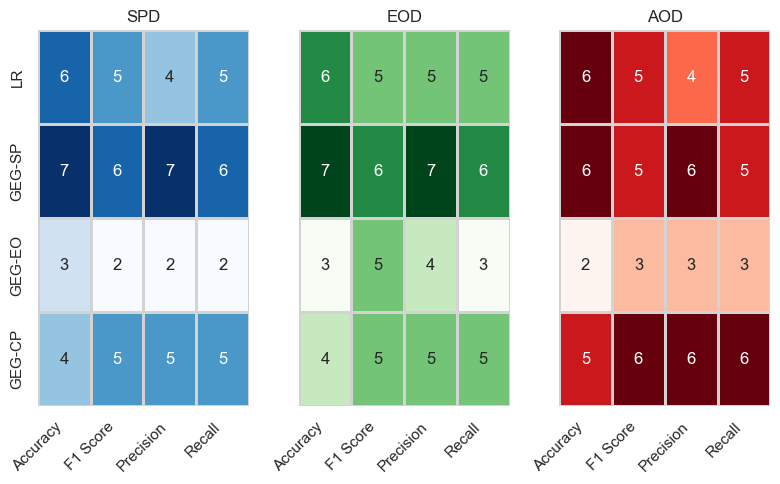

In [121]:
fig, axes = plt.subplots(1, 3, figsize=(8, 5), sharey=True)

# Replace with your real keys
keys = ["SPD", "EOD", "AOD"]
cols = {"SPD":"Blues","EOD":"Greens","AOD":"Reds"}

dfs['SPD'] = dfs['SPD'].reindex(['LR', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['EOD'] = dfs['EOD'].reindex(['LR', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['AOD'] = dfs['AOD'].reindex(['LR', 'GEG-SP', 'GEG-EO', 'GEG-CP'])

for i, (ax, key) in enumerate(zip(axes, keys)):
    sns.heatmap(
        dfs[key],
        cmap=cols[key],
        linewidths=1,
        linecolor="lightgrey",
        annot=True,
        cbar=False,
        ax=ax
    )
    
    # Remove x-axis labels
    ax.set_xlabel(None)
    ax.set_ylabel("")  
    ax.set_xticklabels(['Accuracy', 'F1 Score', 'Precision', 'Recall'], rotation=45, ha="right")
    ax.set_title(key, fontsize=12)

plt.tight_layout()
plt.savefig("imgs/heatmaps_combined-v1.pdf", bbox_inches="tight")
plt.show()

## RQ3

In [122]:
baseline_df = pd.DataFrame()
for file in os.listdir('results_demv'):
    if file.endswith('.csv'):
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_demv', file))
        df['data'] = data
        baseline_df = pd.concat([baseline_df, df], ignore_index=True)
grouped_demv = baseline_df.groupby('data').agg(['mean', 'std']).reset_index()
grouped_demv = grouped_demv.drop(columns='fold')
grouped_demv['constraint'] = 'demv'

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_91084/857907954.py:9: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_demv = grouped_demv.drop(columns='fold')


In [123]:
blackbox_df = pd.DataFrame()
for file in os.listdir('results_blackbox'):
    if file.endswith('.csv'):
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_blackbox', file))
        df['data'] = data
        blackbox_df = pd.concat([blackbox_df, df], ignore_index=True)
grouped_blackbox = blackbox_df.groupby('data').agg(['mean', 'std']).reset_index()
grouped_blackbox = grouped_blackbox.drop(columns='fold')
grouped_blackbox['constraint'] = 'blackbox'

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_91084/156202595.py:9: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_blackbox = grouped_blackbox.drop(columns='fold')


In [124]:
full_data = pd.concat([grouped_demv, grouped_blackbox, grouped_geg], ignore_index=True)

In [125]:
full_data['acc'] = full_data[('accuracy', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('accuracy', 'std')].round(3).astype(str)
full_data['prec'] = full_data[('precision', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('precision', 'std')].round(3).astype(str)
full_data['rec'] = full_data[('recall', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('recall', 'std')].round(3).astype(str)
full_data['f1'] = full_data[('f1_score', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('f1_score', 'std')].round(3).astype(str)
full_data['spd'] = full_data[('statistical_parity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('statistical_parity', 'std')].round(3).astype(str)
full_data['eod'] = full_data[('equal_opportunity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('equal_opportunity', 'std')].round(3).astype(str)
full_data['aod'] = full_data[('average_odds', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('average_odds', 'std')].round(3).astype(str)
full_data.sort_values(by=['data'], inplace=True)
table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds'], axis=1)

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_91084/1697430065.py:9: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds'], axis=1)


In [126]:
table_tex

,data,constraint,acc,prec,rec,f1,spd,eod,aod
,,,,,,,,,
0,cmc,demv,0.601$\pm$0.024,0.581$\pm$0.036,0.55$\pm$0.018,0.542$\pm$0.02,0.056$\pm$0.044,0.053$\pm$0.163,0.036$\pm$0.065
16,cmc,eo,0.601$\pm$0.034,0.574$\pm$0.038,0.56$\pm$0.031,0.557$\pm$0.032,0.028$\pm$0.045,0.01$\pm$0.171,0.007$\pm$0.076
15,cmc,dp,0.602$\pm$0.028,0.575$\pm$0.032,0.556$\pm$0.026,0.549$\pm$0.027,0.015$\pm$0.057,-0.045$\pm$0.147,-0.02$\pm$0.063
14,cmc,cp,0.606$\pm$0.03,0.576$\pm$0.038,0.561$\pm$0.032,0.556$\pm$0.034,0.058$\pm$0.062,0.057$\pm$0.162,0.042$\pm$0.087
7,cmc,blackbox,0.384$\pm$0.071,0.362$\pm$0.071,0.364$\pm$0.073,0.352$\pm$0.072,-0.097$\pm$0.197,-0.096$\pm$0.284,-0.093$\pm$0.232
19,crime,eo,0.333$\pm$0.077,0.41$\pm$0.107,0.307$\pm$0.081,0.246$\pm$0.11,0.128$\pm$0.111,0.074$\pm$0.234,0.066$\pm$0.136
18,crime,dp,0.406$\pm$0.04,0.403$\pm$0.035,0.397$\pm$0.038,0.392$\pm$0.035,0.028$\pm$0.048,-0.056$\pm$0.174,-0.072$\pm$0.07
8,crime,blackbox,0.207$\pm$0.04,0.197$\pm$0.065,0.202$\pm$0.042,0.174$\pm$0.04,-0.403$\pm$0.084,-0.603$\pm$0.175,-0.516$\pm$0.104
17,crime,cp,0.355$\pm$0.031,0.373$\pm$0.031,0.333$\pm$0.029,0.315$\pm$0.033,0.087$\pm$0.065,0.118$\pm$0.213,0.06$\pm$0.103


In [127]:
compute_statistics('precision', 'prec', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('recall', 'rec', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('f1_score', 'f1', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('statistical_parity', 'spd', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('equal_opportunity', 'eod', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('average_odds', 'aod', 'greater', baseline_df, df_geg2, table_tex)

obesity
data           obesity
constraint          dp
p-val         0.947266
accept             1.0
Name: 0, dtype: object
data           obesity
constraint          cp
p-val         0.460938
accept             1.0
Name: 1, dtype: object
data           obesity
constraint          eo
p-val         0.993164
accept             1.0
Name: 2, dtype: object
crime
data            crime
constraint         dp
p-val         0.72168
accept            1.0
Name: 0, dtype: object
data             crime
constraint          cp
p-val         0.958008
accept             1.0
Name: 1, dtype: object
data             crime
constraint          eo
p-val         0.460938
accept             1.0
Name: 2, dtype: object
cmc
data               cmc
constraint          dp
p-val         0.862305
accept             1.0
Name: 0, dtype: object
data               cmc
constraint          cp
p-val         0.652344
accept             1.0
Name: 1, dtype: object
data               cmc
constraint          eo
p-val         0.6152

In [128]:
compute_statistics('precision', 'prec', 'less', blackbox_df, df_geg2, table_tex)
compute_statistics('recall', 'rec', 'less', blackbox_df, df_geg2, table_tex)
compute_statistics('f1_score', 'f1', 'less', blackbox_df, df_geg2, table_tex)
compute_statistics('statistical_parity', 'spd', 'greater', blackbox_df, df_geg2, table_tex)
compute_statistics('equal_opportunity', 'eod', 'greater', blackbox_df, df_geg2, table_tex)
compute_statistics('average_odds', 'aod', 'greater', blackbox_df, df_geg2, table_tex)

obesity
data           obesity
constraint          dp
p-val         0.000977
accept         0.00293
Name: 0, dtype: object
data           obesity
constraint          cp
p-val         0.000977
accept         0.00293
Name: 1, dtype: object
data           obesity
constraint          eo
p-val         0.000977
accept         0.00293
Name: 2, dtype: object
crime
data             crime
constraint          dp
p-val         0.000977
accept         0.00293
Name: 0, dtype: object
data             crime
constraint          cp
p-val         0.000977
accept         0.00293
Name: 1, dtype: object
data             crime
constraint          eo
p-val         0.000977
accept         0.00293
Name: 2, dtype: object
cmc
data               cmc
constraint          dp
p-val         0.000977
accept         0.00293
Name: 0, dtype: object
data               cmc
constraint          cp
p-val         0.000977
accept         0.00293
Name: 1, dtype: object
data               cmc
constraint          eo
p-val         0.

In [129]:
table_tex.to_latex('results_blackbox_comparison.tex', index=False, escape=False)

In [130]:
baseline_df['constraint'] = 'demv'
blackbox_df['constraint'] = 'blackbox'
df_all = pd.concat([baseline_df, blackbox_df, df_geg2], ignore_index=True)

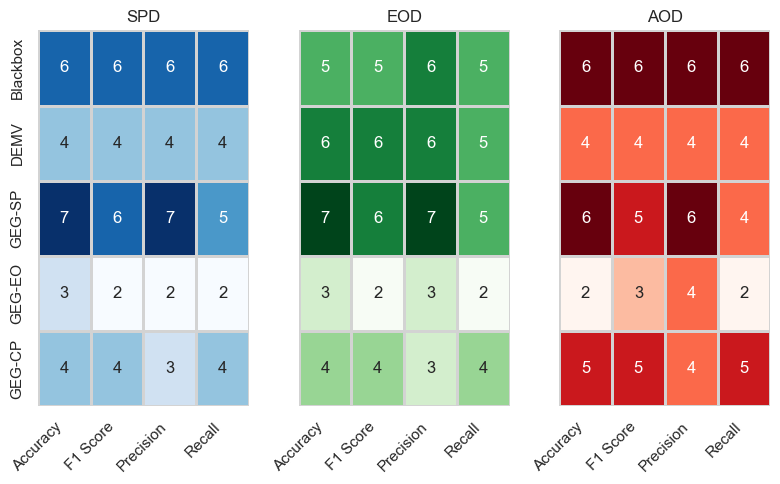

In [131]:
datasets = df_all['data'].unique()
#attrs = ["age","race","sex"]
metricsAcc = ['accuracy', 'precision', 'recall', 'f1_score']
#metricsAcc = ['MCC']
metricsFair = ['statistical_parity', 'equal_opportunity', 'average_odds']
paretoPresent = defaultdict(int)
for dataset in datasets:
  pareto_data = defaultdict(int)
  for mAcc,mFair in product(metricsAcc,metricsFair):
    #filtered = grouped[(grouped["data"]==dataset) & (grouped["attr"]==attr)]
    filtered = df_all[(df_all["data"]==dataset)]
    if not len(filtered):
        continue
    pareto = pareto_front_two(filtered,mAcc,mFair)
    for x in pareto['constraint'].value_counts().keys():
        paretoPresent[(x,mAcc,mFair)] += 1
        pareto_data[x] += 1

df_all = pd.DataFrame(
    [(k[0], k[1], k[2], v) for k, v in paretoPresent.items()],
    columns=["method", "acc", "fair", "value"]
)
uniqueMethods = sorted(df_all["method"].unique())
df_all = df_all.sort_values('method')
# Create pivot tables for each metric2, reindex to include all methods, fill missing with 0
dfs = {}
df_all = df_all.sort_values('method')
for m2 in df_all["fair"].unique():
    pivot = df_all[df_all["fair"] == m2].pivot(
        index="method", columns="acc", values="value"
    )
    dfs[m2] = pivot.reindex(uniqueMethods, fill_value=np.nan)

dfs['statistical_parity'].fillna(0, inplace=True)
dfs['equal_opportunity'].fillna(0, inplace=True)
dfs['average_odds'].fillna(0, inplace=True)

dfs['SPD'] = dfs.pop('statistical_parity')
dfs['EOD'] = dfs.pop('equal_opportunity')
dfs['AOD'] = dfs.pop('average_odds')
rename_map = {
  "blackbox": "Blackbox",
  "demv": "DEMV",
  "dp": "GEG-SP",
  "eo": "GEG-EO",
  "cp": "GEG-CP",
}
dfs['SPD'].rename(index=rename_map, inplace=True)
dfs['EOD'].rename(index=rename_map, inplace=True)
dfs['AOD'].rename(index=rename_map, inplace=True)

dfs['SPD'] = dfs['SPD'].reindex(['Blackbox', 'DEMV', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['EOD'] = dfs['EOD'].reindex(['Blackbox', 'DEMV', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['AOD'] = dfs['AOD'].reindex(['Blackbox', 'DEMV', 'GEG-SP', 'GEG-EO', 'GEG-CP'])

fig, axes = plt.subplots(1, 3, figsize=(8, 5), sharey=True)

# Replace with your real keys
keys = ["SPD", "EOD", "AOD"]
cols = {"SPD":"Blues","EOD":"Greens","AOD":"Reds"}
for i, (ax, key) in enumerate(zip(axes, keys)):
    sns.heatmap(
        dfs[key],
        cmap=cols[key],
        linewidths=1,
        linecolor="lightgrey",
        annot=True,
        cbar=False,
        ax=ax
    )
    
    # Remove x-axis labels
    ax.set_xlabel(None)
    ax.set_ylabel("")  
    ax.set_xticklabels(['Accuracy', 'F1 Score', 'Precision', 'Recall'], rotation=45, ha="right")
    ax.set_title(key, fontsize=12)

plt.tight_layout()
plt.savefig("imgs/heatmaps_combined-v2.pdf", bbox_inches="tight")
plt.show()

## RQ2 

In [133]:
baseline_df = pd.DataFrame()
for file in os.listdir('results_baseline_rq2'):
    if file.endswith('.csv'):
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_baseline_rq2', file))
        df['data'] = data
        baseline_df = pd.concat([baseline_df, df], ignore_index=True)

In [134]:
grouped = baseline_df.groupby('data').agg(['mean', 'std']).reset_index()

In [135]:
grouped_baseline = grouped.drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_91084/2910365511.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_baseline = grouped.drop(columns='fold')


In [136]:
df_geg2 = pd.DataFrame()
for file in os.listdir('results_geg_rq2'):
    if file.endswith('.csv'):
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_geg_rq2', file))
        df['data'] = data
        df_geg2 = pd.concat([df_geg2, df], ignore_index=True)

In [137]:
grouped_geg = df_geg2.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_91084/157383463.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_geg = df_geg2.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')


In [138]:
grouped_baseline['constraint'] = 'baseline'

In [139]:
full_data = pd.concat([grouped_baseline.assign(constraint='baseline'), grouped_geg], ignore_index=True)

In [140]:
full_data.head()

data  accuracy           precision              recall            \
               mean       std      mean       std      mean       std   
0   adult  0.826665  0.006915  0.771957  0.012435  0.726586  0.009579   
1  compas  0.675209  0.021380  0.675343  0.019898  0.666093  0.019814   
2  german  0.745000  0.044284  0.692620  0.063216  0.661321  0.057729   
3   adult  0.769134  0.004880  0.738693  0.024915  0.535491  0.007229   
4   adult  0.824596  0.005983  0.774139  0.012452  0.710732  0.007729   

   f1_score           statistical_parity           equal_opportunity  \
       mean       std               mean       std              mean   
0  0.743824  0.009620          -0.179410  0.015724         -0.154284   
1  0.665794  0.021166          -0.173967  0.040158         -0.102123   
2  0.668692  0.059542          -0.209581  0.107955         -0.182181   
3  0.506410  0.012765          -0.008359  0.007381          0.012244   
4  0.732296  0.008604          -0.076991  0.015889          0.129999   

            average_odds           constraint  
        std         mean       std             
0  0.047611    -0.119063  0.025816   baseline  
1  0.030810    -0.149917  0.041596   baseline  
2  0.170483    -0.169542  0.129837   baseline  
3  0.030731     0.008721  0.016611         cp  
4  0.070503     0.058032  0.036233         dp

In [141]:
full_data['acc'] = full_data[('accuracy', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('accuracy', 'std')].round(3).astype(str)
full_data['prec'] = full_data[('precision', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('precision', 'std')].round(3).astype(str)
full_data['rec'] = full_data[('recall', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('recall', 'std')].round(3).astype(str)
full_data['f1'] = full_data[('f1_score', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('f1_score', 'std')].round(3).astype(str)
full_data['spd'] = full_data[('statistical_parity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('statistical_parity', 'std')].round(3).astype(str)
full_data['eod'] = full_data[('equal_opportunity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('equal_opportunity', 'std')].round(3).astype(str)
full_data['aod'] = full_data[('average_odds', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('average_odds', 'std')].round(3).astype(str)

In [142]:
full_data.sort_values(by=['data', 'constraint'], inplace=True)
table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds'], axis=1)

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_91084/93204417.py:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds'], axis=1)


In [143]:
table_tex


,data,constraint,acc,prec,rec,f1,spd,eod,aod
,,,,,,,,,
0,adult,baseline,0.827$\pm$0.007,0.772$\pm$0.012,0.727$\pm$0.01,0.744$\pm$0.01,-0.179$\pm$0.016,-0.154$\pm$0.048,-0.119$\pm$0.026
3,adult,cp,0.769$\pm$0.005,0.739$\pm$0.025,0.535$\pm$0.007,0.506$\pm$0.013,-0.008$\pm$0.007,0.012$\pm$0.031,0.009$\pm$0.017
4,adult,dp,0.825$\pm$0.006,0.774$\pm$0.012,0.711$\pm$0.008,0.732$\pm$0.009,-0.077$\pm$0.016,0.13$\pm$0.071,0.058$\pm$0.036
5,adult,eo,0.828$\pm$0.004,0.776$\pm$0.009,0.725$\pm$0.005,0.744$\pm$0.005,-0.145$\pm$0.018,-0.051$\pm$0.075,-0.055$\pm$0.038
1,compas,baseline,0.675$\pm$0.021,0.675$\pm$0.02,0.666$\pm$0.02,0.666$\pm$0.021,-0.174$\pm$0.04,-0.102$\pm$0.031,-0.15$\pm$0.042
6,compas,cp,0.611$\pm$0.031,0.695$\pm$0.028,0.578$\pm$0.025,0.52$\pm$0.049,0.001$\pm$0.072,0.014$\pm$0.051,0.019$\pm$0.073
7,compas,dp,0.675$\pm$0.022,0.675$\pm$0.021,0.666$\pm$0.021,0.666$\pm$0.022,-0.049$\pm$0.071,0.014$\pm$0.069,-0.023$\pm$0.068
8,compas,eo,0.669$\pm$0.018,0.669$\pm$0.018,0.66$\pm$0.017,0.66$\pm$0.017,-0.031$\pm$0.055,0.026$\pm$0.041,-0.005$\pm$0.058
2,german,baseline,0.745$\pm$0.044,0.693$\pm$0.063,0.661$\pm$0.058,0.669$\pm$0.06,-0.21$\pm$0.108,-0.182$\pm$0.17,-0.17$\pm$0.13


In [144]:
compute_statistics('accuracy', 'acc', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('precision', 'prec', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('recall', 'rec', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('f1_score', 'f1', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('statistical_parity', 'spd', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('equal_opportunity', 'eod', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('average_odds', 'aod', 'greater', baseline_df, df_geg2, table_tex)

german
data            german
constraint          eo
p-val         0.570312
accept             1.0
Name: 0, dtype: object
data            german
constraint          dp
p-val         0.388672
accept             1.0
Name: 1, dtype: object
data            german
constraint          cp
p-val         0.938477
accept             1.0
Name: 2, dtype: object
compas
data            compas
constraint          eo
p-val         0.930664
accept             1.0
Name: 0, dtype: object
data            compas
constraint          dp
p-val         0.455078
accept             1.0
Name: 1, dtype: object
data          compas
constraint        cp
p-val            1.0
accept           1.0
Name: 2, dtype: object
adult
data             adult
constraint          eo
p-val         0.208008
accept        0.624023
Name: 0, dtype: object
data             adult
constraint          dp
p-val         0.883789
accept             1.0
Name: 1, dtype: object
data          adult
constraint       cp
p-val           1.0
accept  

In [84]:
table_tex.to_latex('results_summary_rq2.tex', index=False, escape=False)

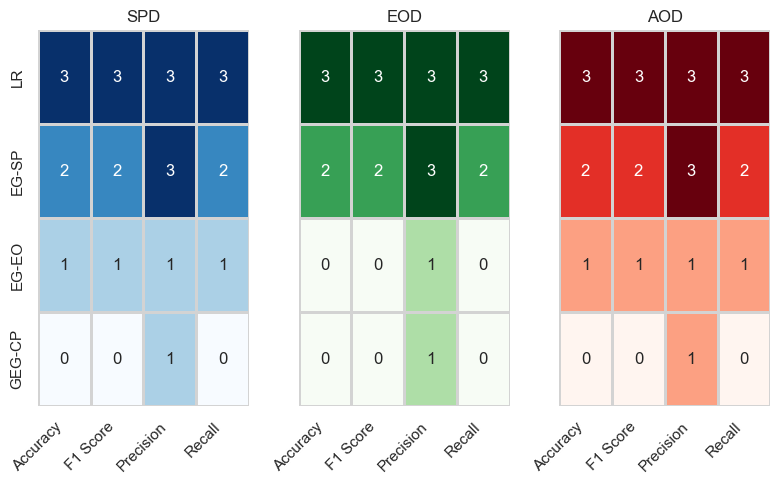

In [147]:
baseline_df['constraint'] = 'LR'
df_all = pd.concat([baseline_df, df_geg2], ignore_index=True)

datasets = df_all['data'].unique()
#attrs = ["age","race","sex"]
metricsAcc = ['accuracy', 'precision', 'recall', 'f1_score']
#metricsAcc = ['MCC']
metricsFair = ['statistical_parity', 'equal_opportunity', 'average_odds']
paretoPresent = defaultdict(int)
for dataset in datasets:
  pareto_data = defaultdict(int)
  for mAcc,mFair in product(metricsAcc,metricsFair):
    #filtered = grouped[(grouped["data"]==dataset) & (grouped["attr"]==attr)]
    filtered = df_all[(df_all["data"]==dataset)]
    if not len(filtered):
        continue
    pareto = pareto_front_two(filtered,mAcc,mFair)
    for x in pareto['constraint'].value_counts().keys():
        paretoPresent[(x,mAcc,mFair)] += 1
        pareto_data[x] += 1

df_all = pd.DataFrame(
    [(k[0], k[1], k[2], v) for k, v in paretoPresent.items()],
    columns=["method", "acc", "fair", "value"]
)
uniqueMethods = sorted(df_all["method"].unique())
df_all = df_all.sort_values('method')
# Create pivot tables for each metric2, reindex to include all methods, fill missing with 0
dfs = {}
df_all = df_all.sort_values('method')
for m2 in df_all["fair"].unique():
    pivot = df_all[df_all["fair"] == m2].pivot(
        index="method", columns="acc", values="value"
    )
    dfs[m2] = pivot.reindex(uniqueMethods, fill_value=np.nan)

dfs['statistical_parity'].fillna(0, inplace=True)
dfs['equal_opportunity'].fillna(0, inplace=True)
dfs['average_odds'].fillna(0, inplace=True)

dfs['SPD'] = dfs.pop('statistical_parity')
dfs['EOD'] = dfs.pop('equal_opportunity')
dfs['AOD'] = dfs.pop('average_odds')
rename_map = {
  "dp": "EG-SP",
  "eo": "EG-EO",
  "cp": "GEG-CP",
}
dfs['SPD'].rename(index=rename_map, inplace=True)
dfs['EOD'].rename(index=rename_map, inplace=True)
dfs['AOD'].rename(index=rename_map, inplace=True)

dfs['SPD'] = dfs['SPD'].reindex(['LR', 'EG-SP', 'EG-EO', 'GEG-CP'])
dfs['EOD'] = dfs['EOD'].reindex(['LR', 'EG-SP', 'EG-EO', 'GEG-CP'])
dfs['AOD'] = dfs['AOD'].reindex(['LR', 'EG-SP', 'EG-EO', 'GEG-CP'])

fig, axes = plt.subplots(1, 3, figsize=(8, 5), sharey=True)

# Replace with your real keys
keys = ["SPD", "EOD", "AOD"]
cols = {"SPD":"Blues","EOD":"Greens","AOD":"Reds"}
for i, (ax, key) in enumerate(zip(axes, keys)):
    sns.heatmap(
        dfs[key],
        cmap=cols[key],
        linewidths=1,
        linecolor="lightgrey",
        annot=True,
        cbar=False,
        ax=ax
    )
    
    # Remove x-axis labels
    ax.set_xlabel(None)
    ax.set_ylabel("")  
    ax.set_xticklabels(['Accuracy', 'F1 Score', 'Precision', 'Recall'], rotation=45, ha="right")
    ax.set_title(key, fontsize=12)

plt.tight_layout()
plt.savefig("imgs/heatmaps_combined-v3.pdf", bbox_inches="tight")
plt.show()

### Comparison with EG

In [ ]:
def compute_statistics_eg(col_name, table_col, condition):
  for data in baseline_df['data'].unique():
    baseline_acc = baseline_df[(baseline_df['data'] == data) & (baseline_df['constraint'] == 'eg_dp')][col_name]
    
    geg_acc = df_geg2[(df_geg2['data'] == data) & (df_geg2['constraint'] == 'cp')][col_name]
    stat = wilcoxon(baseline_acc.abs(), geg_acc.abs(), alternative=condition)
    
    print(f"{data} - cp - p-value: {stat['p-val'].values[0]}")
    

In [15]:
baseline_df = pd.DataFrame()
for file in os.listdir('results_eg'):
    if file.endswith('.csv'):
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_eg', file))
        df['data'] = data
        baseline_df = pd.concat([baseline_df, df], ignore_index=True)

In [16]:
baseline_df = baseline_df[baseline_df['constraint'] == 'eg_dp']

In [17]:
baseline_df

,fold,accuracy,precision,recall,f1_score,statistical_parity,equal_opportunity,average_odds,constraint,data
0,1,0.820000,0.791643,0.750850,0.766112,0.028509,0.028409,0.073728,eg_dp,german
2,3,0.740000,0.687500,0.642857,0.653333,-0.042523,0.037356,-0.101322,eg_dp,german
4,5,0.710000,0.659132,0.621324,0.627776,0.084991,0.049442,0.151994,eg_dp,german
6,7,0.770000,0.707995,0.655758,0.670251,-0.157738,-0.017361,-0.119395,eg_dp,german
8,9,0.720000,0.650480,0.629432,0.636175,-0.150000,-0.092838,-0.150315,eg_dp,german
10,11,0.710000,0.700000,0.659168,0.664002,0.058824,0.142857,0.146141,eg_dp,german
12,13,0.680000,0.548278,0.548278,0.548278,-0.218994,-0.519608,-0.122304,eg_dp,german
14,15,0.830000,0.839964,0.759191,0.781800,0.188347,0.055556,0.206349,eg_dp,german
16,17,0.780000,0.704687,0.693333,0.698465,0.077236,0.038462,0.217760,eg_dp,german
18,19,0.660000,0.611519,0.586813,0.587178,-0.081140,0.081818,-0.030519,eg_dp,german


In [18]:
grouped_demv = baseline_df.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index()
grouped_demv = grouped_demv.drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_65935/2876153373.py:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_demv = grouped_demv.drop(columns='fold')


In [19]:
full_data = pd.concat([grouped_demv, grouped_geg[grouped_geg['constraint'] == 'cp']], ignore_index=True)

In [20]:
full_data['acc'] = full_data[('accuracy', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('accuracy', 'std')].round(3).astype(str)
full_data['prec'] = full_data[('precision', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('precision', 'std')].round(3).astype(str)
full_data['rec'] = full_data[('recall', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('recall', 'std')].round(3).astype(str)
full_data['f1'] = full_data[('f1_score', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('f1_score', 'std')].round(3).astype(str)
full_data['spd'] = full_data[('statistical_parity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('statistical_parity', 'std')].round(3).astype(str)
full_data['eod'] = full_data[('equal_opportunity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('equal_opportunity', 'std')].round(3).astype(str)
full_data['aod'] = full_data[('average_odds', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('average_odds', 'std')].round(3).astype(str)
full_data.sort_values(by=['data'], inplace=True)
table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds'], axis=1)

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_65935/1697430065.py:9: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds'], axis=1)


In [21]:
table_tex

,data,constraint,acc,prec,rec,f1,spd,eod,aod
,,,,,,,,,
0,adult,eg_dp,0.817$\pm$0.006,0.761$\pm$0.014,0.697$\pm$0.009,0.718$\pm$0.01,-0.015$\pm$0.018,0.269$\pm$0.069,0.15$\pm$0.037
3,adult,cp,0.769$\pm$0.005,0.739$\pm$0.025,0.535$\pm$0.007,0.506$\pm$0.013,-0.008$\pm$0.007,0.012$\pm$0.031,0.009$\pm$0.017
1,compas,eg_dp,0.665$\pm$0.019,0.665$\pm$0.021,0.654$\pm$0.019,0.654$\pm$0.019,-0.013$\pm$0.05,0.061$\pm$0.047,0.009$\pm$0.048
4,compas,cp,0.611$\pm$0.031,0.695$\pm$0.028,0.578$\pm$0.025,0.52$\pm$0.049,0.001$\pm$0.072,0.014$\pm$0.051,0.019$\pm$0.073
2,german,eg_dp,0.742$\pm$0.057,0.69$\pm$0.083,0.655$\pm$0.066,0.663$\pm$0.072,-0.021$\pm$0.13,-0.02$\pm$0.186,0.027$\pm$0.147
5,german,cp,0.721$\pm$0.048,0.747$\pm$0.118,0.549$\pm$0.039,0.51$\pm$0.073,-0.026$\pm$0.067,-0.037$\pm$0.052,-0.002$\pm$0.068


In [25]:
compute_statistics_eg('accuracy', 'acc', 'less')
compute_statistics_eg('precision', 'prec', 'less')
compute_statistics_eg('recall', 'rec', 'less')
compute_statistics_eg('f1_score', 'f1', 'less')
compute_statistics_eg('statistical_parity', 'spd', 'greater')
compute_statistics_eg('equal_opportunity', 'eod', 'greater')
compute_statistics_eg('average_odds', 'aod', 'greater')

german - cp - p-value: 0.8466796875
adult - cp - p-value: 1.0
compas - cp - p-value: 1.0
german - cp - p-value: 0.052734375
adult - cp - p-value: 0.9931640625
compas - cp - p-value: 0.0244140625
german - cp - p-value: 1.0
adult - cp - p-value: 1.0
compas - cp - p-value: 1.0
german - cp - p-value: 1.0
adult - cp - p-value: 1.0
compas - cp - p-value: 1.0
german - cp - p-value: 0.0419921875
adult - cp - p-value: 0.0244140625
compas - cp - p-value: 0.8623046875
german - cp - p-value: 0.1611328125
adult - cp - p-value: 0.0009765625
compas - cp - p-value: 0.1162109375
german - cp - p-value: 0.0068359375
adult - cp - p-value: 0.0009765625
compas - cp - p-value: 0.8623046875


In [23]:
table_tex.to_latex('results_eg_comparison.tex', index=False, escape=False)

## RQ4

In [6]:
baseline_df = pd.DataFrame()
for file in os.listdir('results_models'):
    if file.endswith('.csv') and '_rf' in file:
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_models', file))
        df['data'] = data
        baseline_df = pd.concat([baseline_df, df], ignore_index=True)

In [7]:
grouped = baseline_df.groupby('data').agg(['mean', 'std']).reset_index()

In [8]:
grouped_baseline = grouped.drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_98294/2910365511.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_baseline = grouped.drop(columns='fold')


In [9]:
df_geg2 = pd.DataFrame()
for file in os.listdir('results_geg_rq4'):
    if file.endswith('.csv') and '_rf' in file:
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_geg_rq4', file))
        df['data'] = data
        df_geg2 = pd.concat([df_geg2, df], ignore_index=True)

In [10]:
grouped_geg = df_geg2.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_98294/157383463.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_geg = df_geg2.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')


In [11]:
grouped_baseline['constraint'] = 'baseline'

In [12]:
full_data = pd.concat([grouped_baseline.assign(constraint='baseline'), grouped_geg], ignore_index=True)

In [13]:
full_data['acc'] = full_data[('accuracy', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('accuracy', 'std')].round(3).astype(str)
full_data['prec'] = full_data[('precision', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('precision', 'std')].round(3).astype(str)
full_data['rec'] = full_data[('recall', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('recall', 'std')].round(3).astype(str)
full_data['f1'] = full_data[('f1_score', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('f1_score', 'std')].round(3).astype(str)
full_data['spd'] = full_data[('statistical_parity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('statistical_parity', 'std')].round(3).astype(str)
full_data['eod'] = full_data[('equal_opportunity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('equal_opportunity', 'std')].round(3).astype(str)
full_data['aod'] = full_data[('average_odds', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('average_odds', 'std')].round(3).astype(str)

In [14]:
full_data.sort_values(by=['data', 'constraint'], inplace=True)

In [15]:
table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds'], axis=1)

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_98294/1130035862.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds'], axis=1)


In [16]:
table_tex

,data,constraint,acc,prec,rec,f1,spd,eod,aod
,,,,,,,,,
0,cmc,baseline,0.98$\pm$0.015,0.979$\pm$0.016,0.977$\pm$0.017,0.978$\pm$0.017,0.136$\pm$0.08,0.022$\pm$0.087,0.012$\pm$0.045
7,cmc,cp,0.794$\pm$0.041,0.833$\pm$0.022,0.833$\pm$0.032,0.79$\pm$0.043,0.04$\pm$0.16,0.01$\pm$0.062,-0.036$\pm$0.083
8,cmc,dp,0.868$\pm$0.022,0.869$\pm$0.02,0.882$\pm$0.02,0.86$\pm$0.025,0.029$\pm$0.092,0.015$\pm$0.083,-0.058$\pm$0.068
9,cmc,eo,0.984$\pm$0.009,0.985$\pm$0.008,0.981$\pm$0.01,0.983$\pm$0.009,0.141$\pm$0.084,0.034$\pm$0.078,0.019$\pm$0.04
1,crime,baseline,0.499$\pm$0.031,0.471$\pm$0.03,0.478$\pm$0.025,0.466$\pm$0.027,0.413$\pm$0.069,0.483$\pm$0.232,0.355$\pm$0.14
10,crime,cp,0.415$\pm$0.04,0.442$\pm$0.032,0.386$\pm$0.03,0.364$\pm$0.036,0.19$\pm$0.046,0.379$\pm$0.226,0.197$\pm$0.113
11,crime,dp,0.437$\pm$0.04,0.441$\pm$0.033,0.411$\pm$0.022,0.395$\pm$0.03,0.155$\pm$0.055,0.307$\pm$0.244,0.139$\pm$0.124
12,crime,eo,0.507$\pm$0.036,0.473$\pm$0.036,0.484$\pm$0.029,0.47$\pm$0.034,0.424$\pm$0.061,0.497$\pm$0.194,0.367$\pm$0.117
2,drug,baseline,0.676$\pm$0.032,0.606$\pm$0.033,0.597$\pm$0.027,0.597$\pm$0.028,0.143$\pm$0.125,0.177$\pm$0.194,0.108$\pm$0.128


In [137]:
compute_statistics('accuracy', 'acc', 'less')
compute_statistics('precision', 'prec', 'less')
compute_statistics('recall', 'rec', 'less')
compute_statistics('f1_score', 'f1', 'less')
compute_statistics('statistical_parity', 'spd', 'greater')
compute_statistics('equal_opportunity', 'eod', 'greater')
compute_statistics('average_odds', 'aod', 'greater')

law
obesity
park
drug
cmc
wine
crime
law
obesity
park
drug
cmc
wine
crime
law
obesity
park
drug
cmc
wine
crime
law
obesity
park
drug
cmc
wine
crime
law
obesity
park
drug
cmc
wine
crime
law
obesity
park
drug
cmc
wine
crime
law
obesity
park
drug
cmc
wine
crime


In [138]:
table_tex.to_latex('results_summary_rq4_rf.tex', index=False, escape=False)

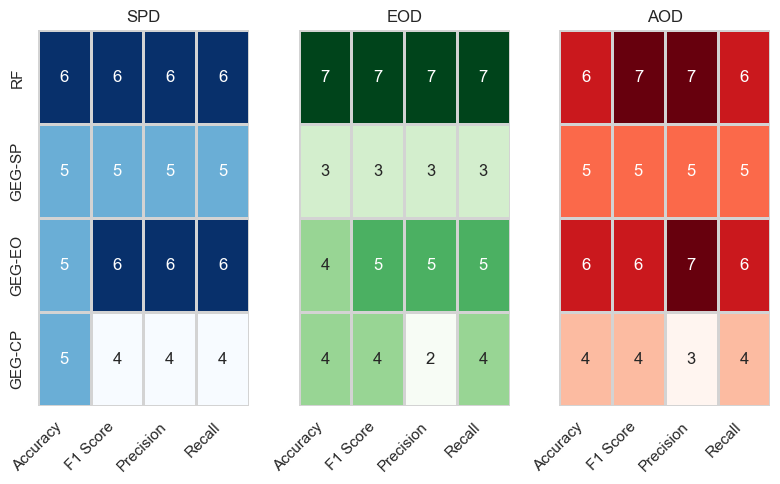

In [23]:
baseline_df['constraint'] = 'RF'
df_all = pd.concat([baseline_df, df_geg2], ignore_index=True)

datasets = df_all['data'].unique()
#attrs = ["age","race","sex"]
metricsAcc = ['accuracy', 'precision', 'recall', 'f1_score']
#metricsAcc = ['MCC']
metricsFair = ['statistical_parity', 'equal_opportunity', 'average_odds']
paretoPresent = defaultdict(int)
for dataset in datasets:
  pareto_data = defaultdict(int)
  for mAcc,mFair in product(metricsAcc,metricsFair):
    #filtered = grouped[(grouped["data"]==dataset) & (grouped["attr"]==attr)]
    filtered = df_all[(df_all["data"]==dataset)]
    if not len(filtered):
        continue
    pareto = pareto_front_two(filtered,mAcc,mFair)
    for x in pareto['constraint'].value_counts().keys():
        paretoPresent[(x,mAcc,mFair)] += 1
        pareto_data[x] += 1

df_all = pd.DataFrame(
    [(k[0], k[1], k[2], v) for k, v in paretoPresent.items()],
    columns=["method", "acc", "fair", "value"]
)
uniqueMethods = sorted(df_all["method"].unique())
df_all = df_all.sort_values('method')
# Create pivot tables for each metric2, reindex to include all methods, fill missing with 0
dfs = {}
df_all = df_all.sort_values('method')
for m2 in df_all["fair"].unique():
    pivot = df_all[df_all["fair"] == m2].pivot(
        index="method", columns="acc", values="value"
    )
    dfs[m2] = pivot.reindex(uniqueMethods, fill_value=np.nan)

dfs['statistical_parity'].fillna(0, inplace=True)
dfs['equal_opportunity'].fillna(0, inplace=True)
dfs['average_odds'].fillna(0, inplace=True)

dfs['SPD'] = dfs.pop('statistical_parity')
dfs['EOD'] = dfs.pop('equal_opportunity')
dfs['AOD'] = dfs.pop('average_odds')
rename_map = {
  "dp": "GEG-SP",
  "eo": "GEG-EO",
  "cp": "GEG-CP",
}
dfs['SPD'].rename(index=rename_map, inplace=True)
dfs['EOD'].rename(index=rename_map, inplace=True)
dfs['AOD'].rename(index=rename_map, inplace=True)

dfs['SPD'] = dfs['SPD'].reindex(['RF', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['EOD'] = dfs['EOD'].reindex(['RF', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['AOD'] = dfs['AOD'].reindex(['RF', 'GEG-SP', 'GEG-EO', 'GEG-CP'])

fig, axes = plt.subplots(1, 3, figsize=(8, 5), sharey=True)

# Replace with your real keys
keys = ["SPD", "EOD", "AOD"]
cols = {"SPD":"Blues","EOD":"Greens","AOD":"Reds"}
for i, (ax, key) in enumerate(zip(axes, keys)):
    sns.heatmap(
        dfs[key],
        cmap=cols[key],
        linewidths=1,
        linecolor="lightgrey",
        annot=True,
        cbar=False,
        ax=ax
    )
    
    # Remove x-axis labels
    ax.set_xlabel(None)
    ax.set_ylabel("")  
    ax.set_xticklabels(['Accuracy', 'F1 Score', 'Precision', 'Recall'], rotation=45, ha="right")
    ax.set_title(key, fontsize=12)

plt.tight_layout()
# plt.savefig("imgs/heatmaps_combined-v3.pdf", bbox_inches="tight")
plt.show()

## Gradient Boosting

In [24]:
baseline_df = pd.DataFrame()
for file in os.listdir('results_models'):
    if file.endswith('.csv') and '_xgb' in file:
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_models', file))
        df['data'] = data
        baseline_df = pd.concat([baseline_df, df], ignore_index=True)

In [25]:
grouped = baseline_df.groupby('data').agg(['mean', 'std']).reset_index()

In [26]:
grouped_baseline = grouped.drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_98294/2910365511.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_baseline = grouped.drop(columns='fold')


In [27]:
df_geg2 = pd.DataFrame()
for file in os.listdir('results_geg_rq4'):
    if file.endswith('.csv') and '_xgb' in file:
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_geg_rq4', file))
        df['data'] = data
        df_geg2 = pd.concat([df_geg2, df], ignore_index=True)

In [28]:
grouped_geg = df_geg2.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_98294/157383463.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_geg = df_geg2.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')


In [29]:
grouped_baseline['constraint'] = 'baseline'

In [30]:
full_data = pd.concat([grouped_baseline.assign(constraint='baseline'), grouped_geg], ignore_index=True)

In [31]:
full_data['acc'] = full_data[('accuracy', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('accuracy', 'std')].round(3).astype(str)
full_data['prec'] = full_data[('precision', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('precision', 'std')].round(3).astype(str)
full_data['rec'] = full_data[('recall', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('recall', 'std')].round(3).astype(str)
full_data['f1'] = full_data[('f1_score', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('f1_score', 'std')].round(3).astype(str)
full_data['spd'] = full_data[('statistical_parity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('statistical_parity', 'std')].round(3).astype(str)
full_data['eod'] = full_data[('equal_opportunity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('equal_opportunity', 'std')].round(3).astype(str)
full_data['aod'] = full_data[('average_odds', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('average_odds', 'std')].round(3).astype(str)

In [32]:
full_data.sort_values(by=['data', 'constraint'], inplace=True)

In [33]:
table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds'], axis=1)

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_98294/1130035862.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds'], axis=1)


In [34]:
table_tex

,data,constraint,acc,prec,rec,f1,spd,eod,aod
,,,,,,,,,
0,cmc,baseline,0.996$\pm$0.005,0.995$\pm$0.006,0.996$\pm$0.005,0.995$\pm$0.005,0.134$\pm$0.104,0.011$\pm$0.017,0.004$\pm$0.008
7,cmc,cp,0.801$\pm$0.062,0.844$\pm$0.033,0.841$\pm$0.042,0.798$\pm$0.062,0.04$\pm$0.134,0.007$\pm$0.014,-0.044$\pm$0.071
8,cmc,dp,0.869$\pm$0.033,0.877$\pm$0.027,0.886$\pm$0.029,0.861$\pm$0.035,-0.014$\pm$0.113,0.004$\pm$0.012,-0.09$\pm$0.027
9,cmc,eo,0.996$\pm$0.005,0.995$\pm$0.006,0.996$\pm$0.005,0.995$\pm$0.005,0.134$\pm$0.104,0.011$\pm$0.017,0.004$\pm$0.008
1,crime,baseline,0.492$\pm$0.046,0.468$\pm$0.045,0.472$\pm$0.038,0.463$\pm$0.041,0.417$\pm$0.042,0.534$\pm$0.216,0.38$\pm$0.101
10,crime,cp,0.364$\pm$0.047,0.4$\pm$0.06,0.339$\pm$0.04,0.32$\pm$0.048,0.179$\pm$0.085,0.342$\pm$0.265,0.208$\pm$0.124
11,crime,dp,0.425$\pm$0.044,0.43$\pm$0.046,0.408$\pm$0.04,0.404$\pm$0.041,0.04$\pm$0.058,0.127$\pm$0.266,-0.009$\pm$0.136
12,crime,eo,0.481$\pm$0.038,0.454$\pm$0.037,0.462$\pm$0.034,0.452$\pm$0.035,0.34$\pm$0.041,0.362$\pm$0.18,0.265$\pm$0.087
2,drug,baseline,0.676$\pm$0.031,0.606$\pm$0.032,0.602$\pm$0.027,0.6$\pm$0.029,0.167$\pm$0.13,0.18$\pm$0.156,0.127$\pm$0.115


In [14]:
compute_statistics('precision', 'prec', 'less')
compute_statistics('recall', 'rec', 'less')
compute_statistics('f1_score', 'f1', 'less')
compute_statistics('statistical_parity', 'spd', 'greater')
compute_statistics('equal_opportunity', 'eod', 'greater')
compute_statistics('average_odds', 'aod', 'greater')

park
cmc
law
crime
drug
obesity
wine
park


/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: RuntimeWarning: invalid value encountered in scalar divide
  rbc = r_plus / rsum - r_minus / rsum
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: RuntimeWarning: invalid value encountered in scalar divide
  rbc = r_plus / rsum - r_minus / rsum
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: Run

cmc
law
crime
drug
obesity


/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: RuntimeWarning: invalid value encountered in scalar divide
  rbc = r_plus / rsum - r_minus / rsum
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: RuntimeWarning: invalid value encountered in scalar divide
  rbc = r_plus / rsum - r_minus / rsum
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: Run

wine
park
cmc
law
crime
drug
obesity
wine
park
cmc


...

/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: RuntimeWarning: invalid value encountered in scalar divide
  rbc = r_plus / rsum - r_minus / rsum
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: RuntimeWarning: invalid value encountered in scalar divide
  rbc = r_plus / rsum - r_minus / rsum
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: Run

crime
drug
obesity


/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: RuntimeWarning: invalid value encountered in scalar divide
  rbc = r_plus / rsum - r_minus / rsum
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: RuntimeWarning: invalid value encountered in scalar divide
  rbc = r_plus / rsum - r_minus / rsum
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: Run

wine
park
cmc
law
crime
drug
obesity
wine


/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: RuntimeWarning: invalid value encountered in scalar divide
  rbc = r_plus / rsum - r_minus / rsum
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: RuntimeWarning: invalid value encountered in scalar divide
  rbc = r_plus / rsum - r_minus / rsum
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: Run

In [15]:
table_tex.to_latex('results_summary_rq4_xgb.tex', index=False, escape=False)

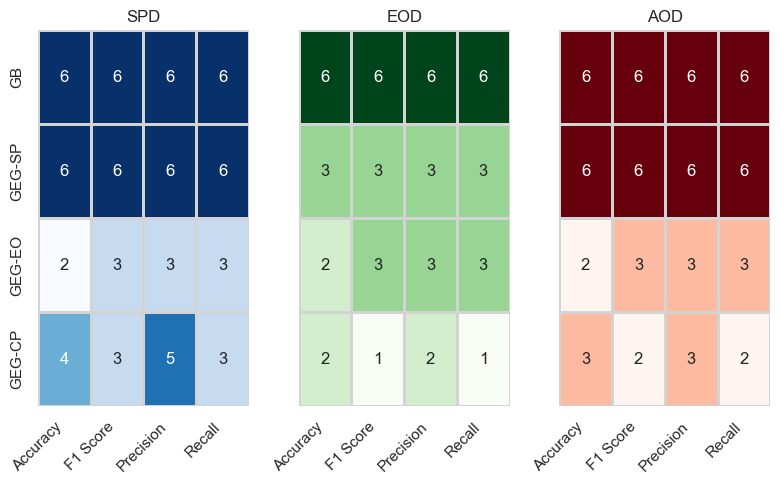

In [36]:
baseline_df['constraint'] = 'GB'
df_all = pd.concat([baseline_df, df_geg2], ignore_index=True)

datasets = df_all['data'].unique()
#attrs = ["age","race","sex"]
metricsAcc = ['accuracy', 'precision', 'recall', 'f1_score']
#metricsAcc = ['MCC']
metricsFair = ['statistical_parity', 'equal_opportunity', 'average_odds']
paretoPresent = defaultdict(int)
for dataset in datasets:
  pareto_data = defaultdict(int)
  for mAcc,mFair in product(metricsAcc,metricsFair):
    #filtered = grouped[(grouped["data"]==dataset) & (grouped["attr"]==attr)]
    filtered = df_all[(df_all["data"]==dataset)]
    if not len(filtered):
        continue
    pareto = pareto_front_two(filtered,mAcc,mFair)
    for x in pareto['constraint'].value_counts().keys():
        paretoPresent[(x,mAcc,mFair)] += 1
        pareto_data[x] += 1

df_all = pd.DataFrame(
    [(k[0], k[1], k[2], v) for k, v in paretoPresent.items()],
    columns=["method", "acc", "fair", "value"]
)
uniqueMethods = sorted(df_all["method"].unique())
df_all = df_all.sort_values('method')
# Create pivot tables for each metric2, reindex to include all methods, fill missing with 0
dfs = {}
df_all = df_all.sort_values('method')
for m2 in df_all["fair"].unique():
    pivot = df_all[df_all["fair"] == m2].pivot(
        index="method", columns="acc", values="value"
    )
    dfs[m2] = pivot.reindex(uniqueMethods, fill_value=np.nan)

dfs['statistical_parity'].fillna(0, inplace=True)
dfs['equal_opportunity'].fillna(0, inplace=True)
dfs['average_odds'].fillna(0, inplace=True)

dfs['SPD'] = dfs.pop('statistical_parity')
dfs['EOD'] = dfs.pop('equal_opportunity')
dfs['AOD'] = dfs.pop('average_odds')
rename_map = {
  "dp": "GEG-SP",
  "eo": "GEG-EO",
  "cp": "GEG-CP",
}
dfs['SPD'].rename(index=rename_map, inplace=True)
dfs['EOD'].rename(index=rename_map, inplace=True)
dfs['AOD'].rename(index=rename_map, inplace=True)

dfs['SPD'] = dfs['SPD'].reindex(['GB', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['EOD'] = dfs['EOD'].reindex(['GB', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['AOD'] = dfs['AOD'].reindex(['GB', 'GEG-SP', 'GEG-EO', 'GEG-CP'])

fig, axes = plt.subplots(1, 3, figsize=(8, 5), sharey=True)

# Replace with your real keys
keys = ["SPD", "EOD", "AOD"]
cols = {"SPD":"Blues","EOD":"Greens","AOD":"Reds"}
for i, (ax, key) in enumerate(zip(axes, keys)):
    sns.heatmap(
        dfs[key],
        cmap=cols[key],
        linewidths=1,
        linecolor="lightgrey",
        annot=True,
        cbar=False,
        ax=ax
    )
    
    # Remove x-axis labels
    ax.set_xlabel(None)
    ax.set_ylabel("")  
    ax.set_xticklabels(['Accuracy', 'F1 Score', 'Precision', 'Recall'], rotation=45, ha="right")
    ax.set_title(key, fontsize=12)

plt.tight_layout()
plt.savefig("imgs/heatmaps_combined-v5.pdf", bbox_inches="tight")
plt.show()